# Task 1 · Step 1 — Standard DPO (one epoch)

**Objective.** For a prompt $x$ with preferred / rejected responses $(y^+, y^-)$, a trainable policy $\pi_\theta$ and the frozen reference $\pi_{\text{ref}}$,
$$\mathcal{L}_{\text{DPO}}(\theta)=-\mathbb{E}\Big[\log\sigma\Big(\beta\Big[\log\tfrac{\pi_\theta(y^+|x)}{\pi_{\text{ref}}(y^+|x)}-\log\tfrac{\pi_\theta(y^-|x)}{\pi_{\text{ref}}(y^-|x)}\Big]\Big)\Big],$$
with sequence log-probabilities summed over response tokens only (teacher forcing).

**Setting.** Policy = `Qwen/Qwen2.5-1.5B-Instruct` + a fresh LoRA adapter (r = 8, α = 16, dropout 0.05, `q_proj`/`v_proj`); reference = the same network with the adapter disabled. AdamW, lr 2e-5, 2 pairs × 8 accumulation steps = 16 pairs per optimizer step, gradient clipping 1.0, seed 6304, fp16 on a T4.

**Sequence-length policy (TA clarification, 3 Oct).** Some prompt + response pairs exceed the 768-token limit. For every DPO training *and* evaluation run the prompt is kept intact and an over-length response is right-truncated (no EOS is appended to a cut response); pairs whose prompt leaves fewer than 64 response tokens are dropped. The same rule is used for all conditions.

**This notebook.** Configuration → validated objective → data and truncation policy → full training log → held-out preference metrics (289 pairs) → held-out generation metrics against the untouched SFT policy (200 prompts, identical sampling seed) → paired comparison → qualitative examples → facts for the step question.

**Pipeline commands.** `python -m task1_dpo.preprocess`, `python -m task1_dpo.evaluate --adapter none --name sft_reference`, `python -m task1_dpo.train --run-name standard`, `python -m task1_dpo.evaluate --adapter outputs/task1_dpo/standard --name standard` (all with `--config configs/dpo.yaml`).


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## 1. Configuration

In [2]:
cfg = load_yaml("configs/dpo.yaml")
keys = ["base_model", "beta", "learning_rate", "batch_size", "grad_accum_steps", "epochs", "max_sequence_length",
        "min_response_tokens", "max_generation_tokens", "eval_generation_prompts", "reward_model", "reward_max_length", "seed", "dtype"]
conf = pd.DataFrame({"value": [str(cfg.get(k)) for k in keys]}, index=keys)
conf.loc["lora"] = str(cfg["lora"]); conf.loc["generation (eval)"] = str(cfg["generation"])
conf

,value
base_model,Qwen/Qwen2.5-1.5B-Instruct
beta,0.1
learning_rate,2e-05
batch_size,2
grad_accum_steps,8
epochs,1
max_sequence_length,768
min_response_tokens,64
max_generation_tokens,256
eval_generation_prompts,200


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [3]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task1_dpo.preprocess --config configs/dpo.yaml')
    run('python -m task1_dpo.evaluate --config configs/dpo.yaml --adapter none --name sft_reference')
    run('python -m task1_dpo.train --config configs/dpo.yaml --run-name standard')
    run('python -m task1_dpo.evaluate --config configs/dpo.yaml --adapter outputs/task1_dpo/standard --name standard')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## Validated objective (starter defect)
The released `dpo_loss` computed the logit as $\beta\,[(\log\pi_\theta^+-\log\pi_\theta^-) + (\log\pi_{\text{ref}}^+-\log\pi_{\text{ref}}^-)]$, i.e. it **added** the reference margin. The objective above subtracts it, so that the logit is the difference of the two log-ratios. The corrected code and a numerical check (NumPy re-implementation) follow.


In [4]:
src = (ROOT / "task1_dpo" / "dpo.py").read_text(encoding="utf-8")
body = src[src.index("    policy_margin ="):src.index("    loss =")]
print("task1_dpo/dpo.py (corrected lines):\n" + "\n".join(l for l in body.splitlines() if l.strip() and not l.strip().startswith("#")))

def dpo_logit(pc, pr, rc, rr, beta, starter=False):
    return beta * ((pc - pr) + (rc - rr)) if starter else beta * ((pc - pr) - (rc - rr))
softplus = lambda z: np.log1p(np.exp(-z))          # -log sigmoid(z)
cases = {
    "policy == reference (untrained)": (-50.0, -60.0, -50.0, -60.0),
    "policy raises chosen vs ref":      (-45.0, -60.0, -50.0, -60.0),
    "policy raises rejected vs ref":    (-50.0, -55.0, -50.0, -60.0),
}
rows = []
for name, (pc, pr, rc, rr) in cases.items():
    for starter in (True, False):
        z = dpo_logit(pc, pr, rc, rr, 0.1, starter)
        rows.append({"case": name, "implementation": "starter (+ref)" if starter else "corrected (−ref)",
                     "logit": z, "loss": softplus(z)})
pd.DataFrame(rows).pivot(index="case", columns="implementation", values=["logit", "loss"]).round(4)

task1_dpo/dpo.py (corrected lines):
    policy_margin = policy_chosen_logp - policy_rejected_logp
    ref_margin = ref_chosen_logp - ref_rejected_logp
    logits = beta * (policy_margin - ref_margin)


logit                            loss               
implementation                  corrected (−ref) starter (+ref) corrected (−ref) starter (+ref)
case                                                                                           
policy == reference (untrained)              0.0            2.0           0.6931         0.1269
policy raises chosen vs ref                  0.5            2.5           0.4741         0.0789
policy raises rejected vs ref               -0.5            1.5           0.9741         0.2014

With the corrected logit an untrained policy has logit 0 and loss log 2 ≈ 0.693, and the loss moves in the right direction when the policy favours the chosen or the rejected response. The starter version already reports a non-zero logit before any training, determined by the reference model's own preference.

## 2. Data and the 768-token policy
Per file: pairs over the limit, pairs dropped by the prompt filter, and pairs whose chosen and/or rejected response is right-truncated. For comparison, *released rule: prompt cut* counts the pairs whose prompt the released starter would have truncated instead.


In [5]:
pre = load("task1_dpo/dpo_preprocessing_report.json")
rows = []
for name, f in pre["files"].items():
    t = f["total"]
    rows.append({"file": name, "pairs": t.get("pairs"), "over 768 tokens": t.get("overlength_pairs", 0),
                 "dropped (prompt too long)": t.get("dropped_here", 0), "kept": t.get("kept", 0),
                 "response truncated (kept pairs)": t.get("either_truncated_here", 0),
                 "released rule: prompt cut": t.get("released_prompt_cut", 0),
                 "share chosen longer (full)": f["chosen_minus_rejected_tokens_full"]["frac_chosen_longer"],
                 "share chosen longer (after truncation)": f["chosen_minus_rejected_tokens_after_truncation"]["frac_chosen_longer"],
                 "prompt tokens p50 / p90 / p99": " / ".join(f"{f['prompt_tokens_percentiles'][q]:.0f}" for q in ["50", "90", "99"])})
display(pd.DataFrame(rows).set_index("file"))
print("policy:", json.dumps(pre["policy"], indent=1))

,pairs,over 768 tokens,dropped (prompt too long),kept,response truncated (kept pairs),released rule: prompt cut,share chosen longer (full),share chosen longer (after truncation),prompt tokens p50 / p90 / p99
file,,,,,,,,,
dpo_standard_train,1500,286,57,1443,229,286,0.5710,0.5447,111 / 442 / 1165
dpo_standard_eval,300,60,11,289,49,60,0.5329,0.5052,100 / 500 / 1119
dpo_length_train,1500,100,68,1432,33,100,0.4916,0.4860,95 / 445 / 1104
dpo_length_eval,246,16,11,235,5,16,0.4766,0.4723,90 / 446 / 1042


policy: {
 "max_sequence_length": 768,
 "min_response_tokens": 64,
 "prompt": "kept intact",
 "response": "right-truncated to the remaining budget; EOS kept only if the full response fits",
 "filter": "drop pair if rendered prompt > 704 tokens",
 "applies_to": "all DPO training and evaluation runs (standard, beta forks, length-balanced, all held-out sets)"
}


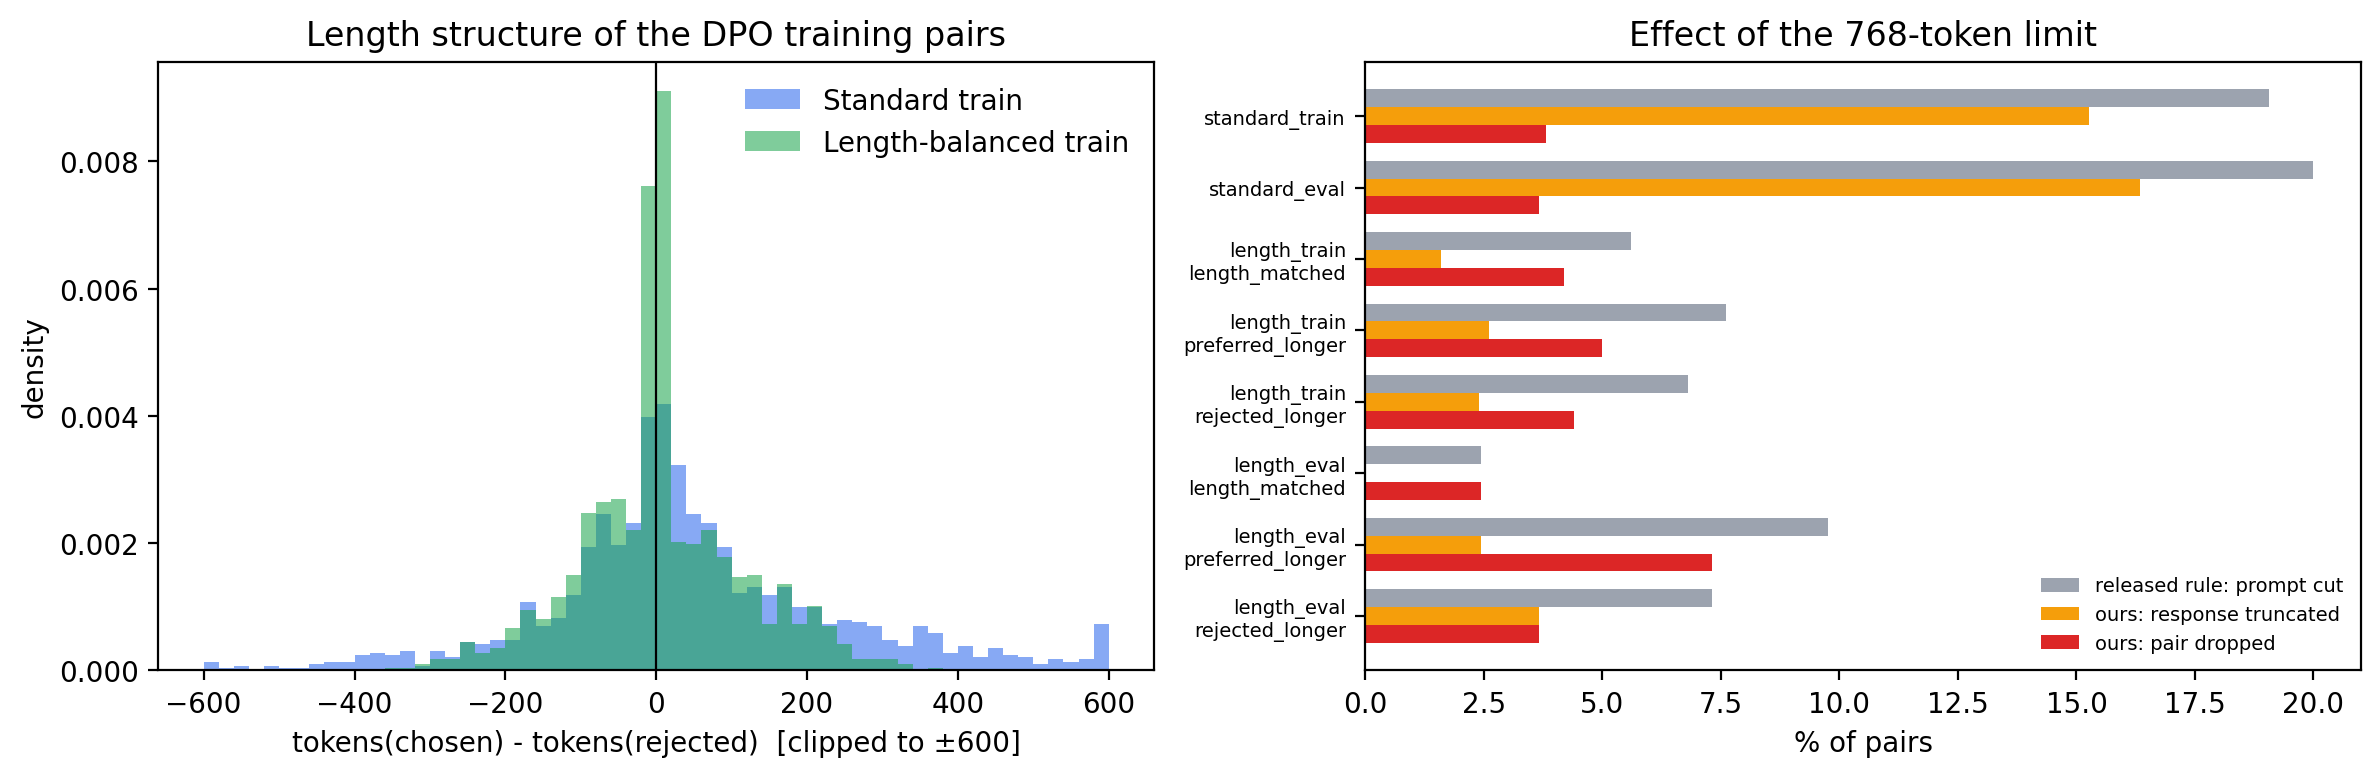

In [6]:
display(Image(filename=str(FIG / "task1_dpo_truncation_policy.png"), width=1000))

## 3. Training log
One row per optimizer step; every value is the mean over the step's 16 pairs (8 micro-batches of 2). The full log is `results/task1_dpo/dpo_train_standard.jsonl`.


In [7]:
log = pd.DataFrame(jl("task1_dpo/dpo_train_standard.jsonl"))
s = load("task1_dpo/dpo_summary_standard.json")
print(f"{s['total_steps']} optimizer steps over {s['dataset_size']} kept pairs ({s['data']['dropped_overlength']} dropped of "
      f"{s['data']['rows_in_file']}); wall-clock {s['wall_time_seconds']/60:.1f} min; peak VRAM {s['peak_vram_mb']/1024:.2f} GB")
cols = ["step", "pairs_in_step", "loss", "preference_accuracy", "implicit_chosen_reward_mean", "implicit_rejected_reward_mean",
        "reward_margin_mean", "kl_chosen", "grad_norm", "response_truncated_frac"]
log[cols][(log.step % 10 == 0) | (log.step == 1) | (log.step == log.step.max())].set_index("step").round(4)

91 optimizer steps over 1443 kept pairs (57 dropped of 1500); wall-clock 20.0 min; peak VRAM 7.11 GB


,pairs_in_step,loss,preference_accuracy,implicit_chosen_reward_mean,implicit_rejected_reward_mean,reward_margin_mean,kl_chosen,grad_norm,response_truncated_frac
step,,,,,,,,,
1,16,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,1.8630,0.1250
10,16,0.6957,0.3125,-0.0037,0.0013,-0.0050,-0.0371,2.2535,0.1875
20,16,0.6893,0.6250,0.0094,0.0017,0.0077,0.0942,2.1388,0.0625
30,16,0.6932,0.4375,-0.0025,-0.0026,0.0001,-0.0253,1.8878,0.1250
40,16,0.6918,0.5625,-0.0266,-0.0298,0.0032,-0.2658,1.5566,0.1250
50,16,0.6907,0.5000,-0.0240,-0.0300,0.0061,-0.2396,2.0170,0.0625
60,16,0.6901,0.7500,-0.0029,-0.0109,0.0080,-0.0294,1.9054,0.1250
70,16,0.6798,0.6250,0.0049,-0.0248,0.0297,0.0491,1.9969,0.1250
80,16,0.6847,0.6250,-0.0476,-0.0675,0.0200,-0.4756,2.1575,0.3125


(curves omit 1 partial accumulation window(s): step 91 = 4 pairs)


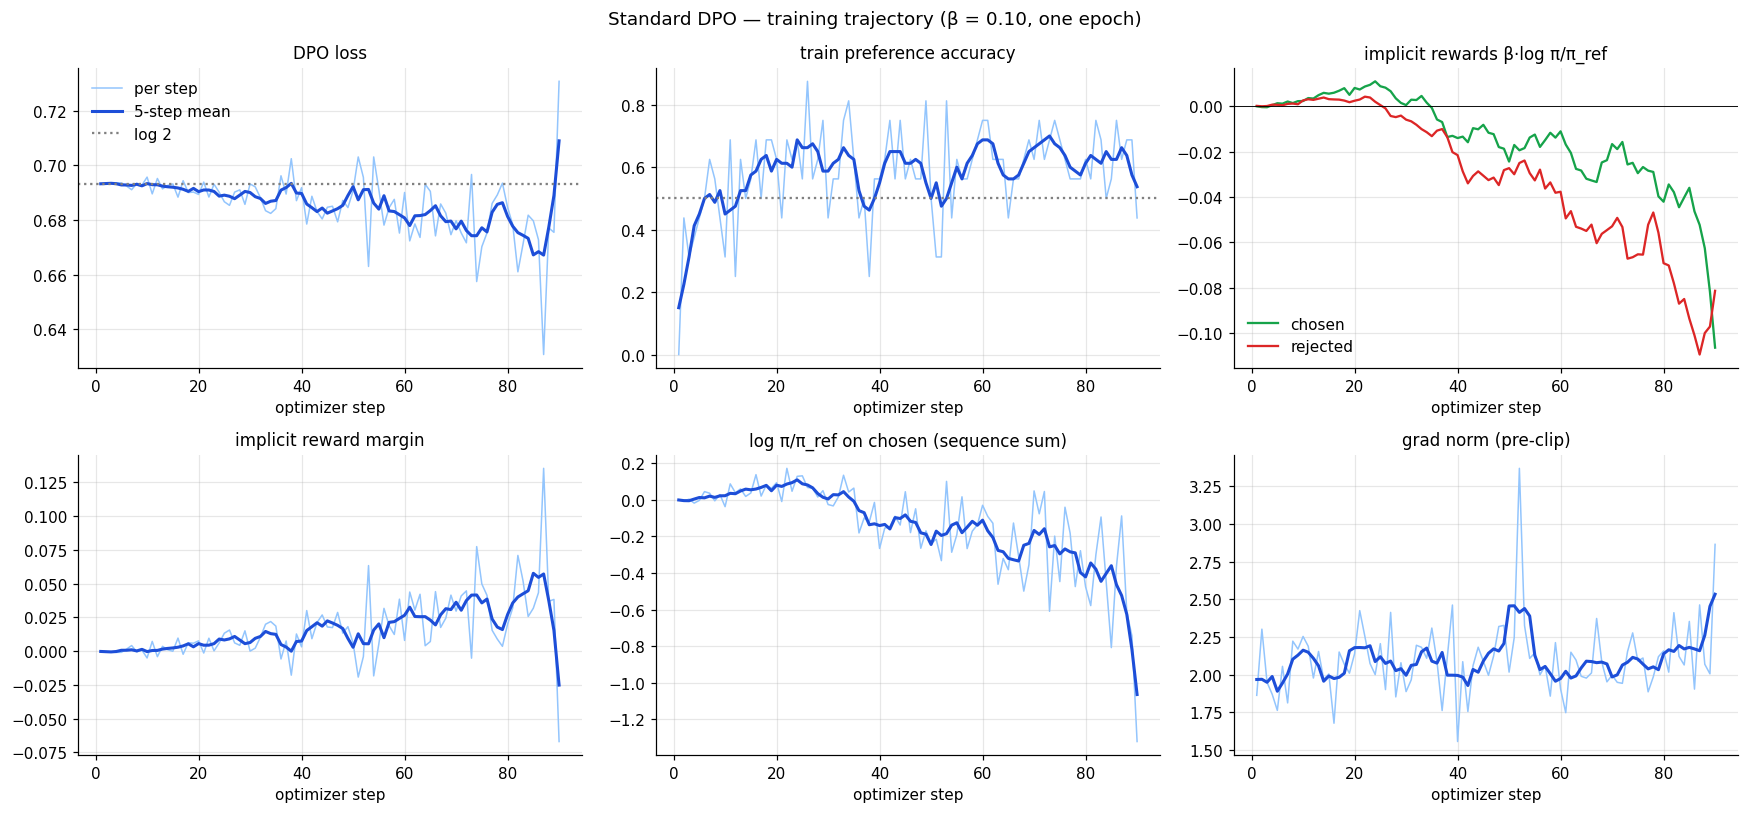

In [8]:
log = full_windows(log)
fig, ax = plt.subplots(2, 3, figsize=(16, 7.5))
panels = [("loss", "DPO loss"), ("preference_accuracy", "train preference accuracy"), (None, "implicit rewards β·log π/π_ref"),
          ("reward_margin_mean", "implicit reward margin"), ("kl_chosen", "log π/π_ref on chosen (sequence sum)"), ("grad_norm", "grad norm (pre-clip)")]
for a, (k, t) in zip(ax.flat, panels):
    if k is None:
        a.plot(log.step, smooth(log.implicit_chosen_reward_mean), color="#16A34A", label="chosen")
        a.plot(log.step, smooth(log.implicit_rejected_reward_mean), color="#DC2626", label="rejected")
        a.axhline(0, color="k", lw=0.6); a.legend()
    else:
        a.plot(log.step, log[k], color="#93C5FD", lw=1, label="per step")
        a.plot(log.step, smooth(log[k]), color="#1D4ED8", lw=2, label="5-step mean")
    if k == "loss": a.axhline(np.log(2), color="gray", ls=":", label="log 2"); a.legend()
    if k == "preference_accuracy": a.axhline(0.5, color="gray", ls=":")
    a.set_title(t); a.set_xlabel("optimizer step")
fig.suptitle("Standard DPO — training trajectory (β = 0.10, one epoch)"); fig.tight_layout(); plt.show()

## 4. Held-out preference metrics
Held-out DPO loss and preference accuracy on the filtered held-out pairs. Margin $m_\theta=[\log\pi_\theta-\log\pi_{\text{ref}}](y^+)-[\log\pi_\theta-\log\pi_{\text{ref}}](y^-)$; accuracy = share with $m_\theta>0$. For the SFT policy every margin is exactly 0 (policy = reference), so its accuracy is 0 with all pairs tied and its loss is log 2.


In [9]:
sft, std = load("task1_dpo/dpo_eval_sft_reference.json"), load("task1_dpo/dpo_eval_standard.json")
k = int(round(std["heldout_preference_accuracy"] * std["num_pairs"]))
lo, hi = wilson_interval(k, std["num_pairs"])
pd.DataFrame({
    "SFT (no adapter)": [sft["num_pairs"], sft["heldout_dpo_loss"], sft["heldout_preference_accuracy"], sft["heldout_tie_fraction"], sft["mean_margin"], "—"],
    "standard DPO": [std["num_pairs"], std["heldout_dpo_loss"], std["heldout_preference_accuracy"], std["heldout_tie_fraction"], std["mean_margin"], f"[{lo:.3f}, {hi:.3f}]"],
}, index=["pairs", "held-out DPO loss (β=0.1)", "preference accuracy", "tied pairs", "mean margin (nats)", "accuracy 95% CI"])

,SFT (no adapter),standard DPO
pairs,289,289
held-out DPO loss (β=0.1),0.6931,0.6752
preference accuracy,0.0,0.6367
tied pairs,1.0,0.0
mean margin (nats),0.0,0.4231
accuracy 95% CI,—,"[0.580, 0.690]"


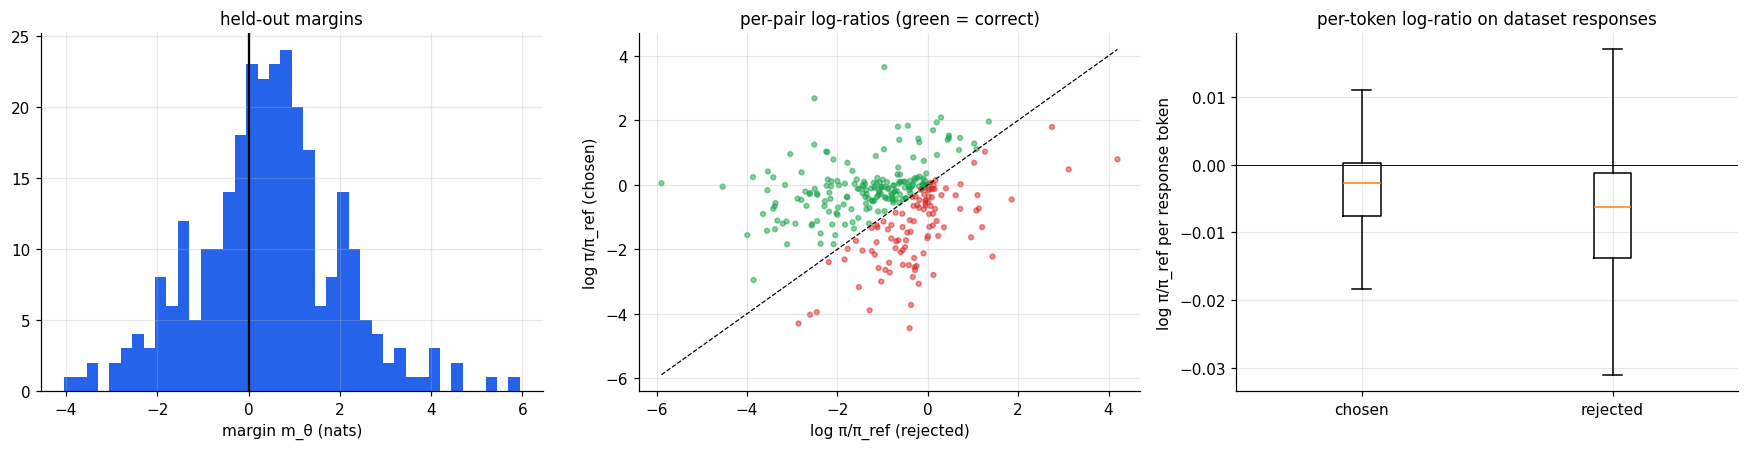

mean per-token log-ratio: chosen -0.00493 | rejected -0.01463


In [10]:
pp = pd.DataFrame(std["per_pair"])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(pp.margin, bins=40, color="#2563EB"); ax[0].axvline(0, color="k"); ax[0].set_xlabel("margin m_θ (nats)"); ax[0].set_title("held-out margins")
ax[1].scatter(pp.logratio_rejected, pp.logratio_chosen, s=10, alpha=0.5, c=np.where(pp.margin > 0, "#16A34A", "#DC2626"))
lim = [min(pp.logratio_rejected.min(), pp.logratio_chosen.min()), max(pp.logratio_rejected.max(), pp.logratio_chosen.max())]
ax[1].plot(lim, lim, "k--", lw=0.8); ax[1].set_xlabel("log π/π_ref (rejected)"); ax[1].set_ylabel("log π/π_ref (chosen)")
ax[1].set_title("per-pair log-ratios (green = correct)")
per_tok = pd.DataFrame({"chosen": pp.logratio_chosen / pp.chosen_tokens_kept, "rejected": pp.logratio_rejected / pp.rejected_tokens_kept})
ax[2].boxplot([per_tok.chosen, per_tok.rejected], tick_labels=["chosen", "rejected"], showfliers=False)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_ylabel("log π/π_ref per response token"); ax[2].set_title("per-token log-ratio on dataset responses")
fig.tight_layout(); plt.show()
print("mean per-token log-ratio: chosen %+.5f | rejected %+.5f" % (per_tok.chosen.mean(), per_tok.rejected.mean()))

## 5. Held-out generations: SFT vs standard DPO
The first 200 kept held-out prompts, sampled with the course generation settings (T = 0.7, top-p 0.9, cap 256 tokens) and the same seed for both policies. Reward = fixed course reward model. KL = released sampled-response estimator (token mean of $\log\pi_\theta-\log\pi_{\text{ref}}$ on the policy's own generations); the per-response sum is shown as the sequence-level view.


In [11]:
def gen_row(e):
    L = e["length_tokens"]
    return {"RM score": f"{e['mean_reward']:.3f} ± {e['sem_reward']:.3f}", "RM std": e["std_reward"],
            "KL token-mean": e["kl_token_mean"], "KL sequence-mean": e["kl_sequence_mean"],
            "entropy (exact)": e["entropy_exact"], "length mean ± std": f"{L['mean']:.1f} ± {L['std']:.1f}",
            "length median [IQR]": f"{L['median']:.0f} [{L['q25']:.0f}, {L['q75']:.0f}]", "EOS rate": e["eos_rate"],
            "hit 256 cap": e["hit_max_tokens_rate"], "corr(RM, length)": e["reward_length_corr"]}
pd.DataFrame({"SFT (no adapter)": gen_row(sft), "standard DPO": gen_row(std)})

,SFT (no adapter),standard DPO
RM score,1.282 ± 0.086,1.299 ± 0.085
RM std,1.2174,1.2025
KL token-mean,0.0,0.0005
KL sequence-mean,0.0,0.0819
entropy (exact),0.9459,0.9573
length mean ± std,162.6 ± 102.6,158.8 ± 102.1
length median [IQR],"222 [50, 256]","195 [49, 256]"
EOS rate,0.55,0.57
hit 256 cap,0.45,0.43
"corr(RM, length)",-0.0408,-0.0319


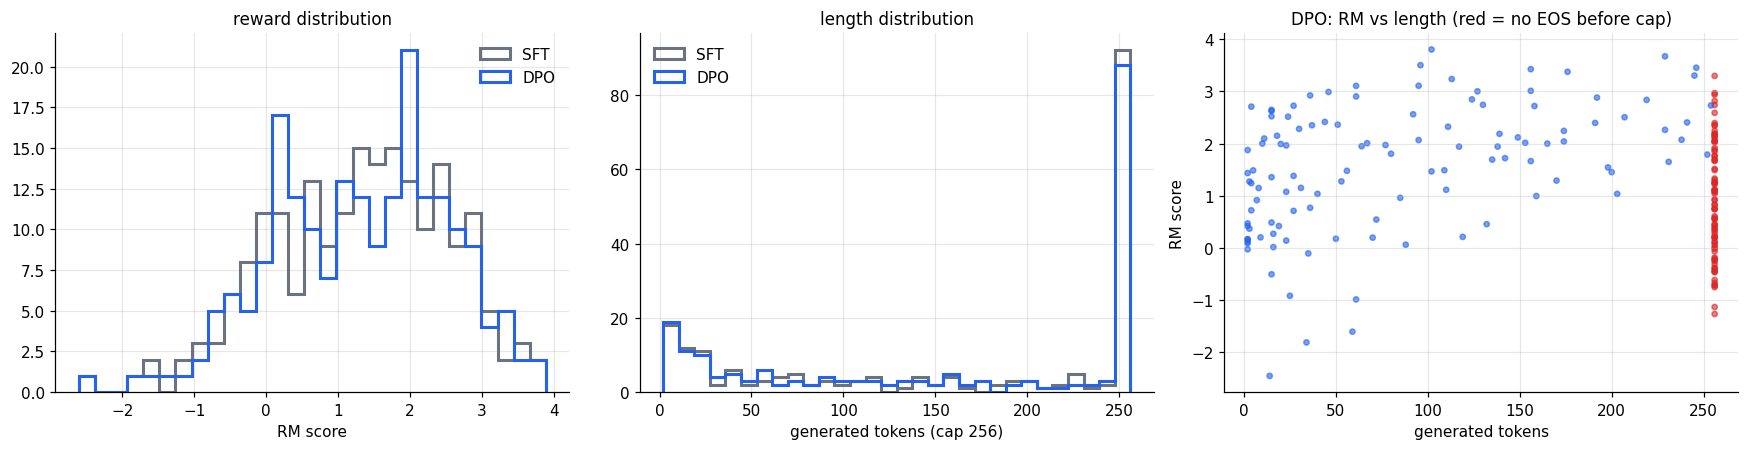

SFT: RM finished 1.566 (n=110) | RM unfinished 0.936 (n=90)
DPO: RM finished 1.582 (n=114) | RM unfinished 0.923 (n=86)


In [12]:
G = {n: pd.DataFrame(e["generations"]) for n, e in [("SFT", sft), ("DPO", std)]}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
bins = np.linspace(min(g.reward_score.min() for g in G.values()), max(g.reward_score.max() for g in G.values()), 30)
for n, c in [("SFT", "#6B7280"), ("DPO", "#2563EB")]:
    ax[0].hist(G[n].reward_score, bins=bins, histtype="step", lw=2, color=c, label=n)
    ax[1].hist(G[n].response_length_tokens, bins=30, histtype="step", lw=2, color=c, label=n)
ax[0].set_xlabel("RM score"); ax[0].legend(); ax[0].set_title("reward distribution")
ax[1].set_xlabel("generated tokens (cap 256)"); ax[1].legend(); ax[1].set_title("length distribution")
g = G["DPO"]
ax[2].scatter(g.response_length_tokens, g.reward_score, s=12, alpha=0.6, c=np.where(g.terminated_with_eos, "#2563EB", "#DC2626"))
ax[2].set_xlabel("generated tokens"); ax[2].set_ylabel("RM score"); ax[2].set_title("DPO: RM vs length (red = no EOS before cap)")
fig.tight_layout(); plt.show()
for n in G:
    fin = G[n][G[n].terminated_with_eos]; cap = G[n][~G[n].terminated_with_eos]
    print(f"{n}: RM finished {fin.reward_score.mean():.3f} (n={len(fin)}) | RM unfinished {cap.reward_score.mean():.3f} (n={len(cap)})")

In [13]:
m = G["SFT"].merge(G["DPO"], on="prompt_id", suffixes=("_sft", "_dpo"))
d, lo, hi = bootstrap_mean_diff(m.reward_score_dpo, m.reward_score_sft)
dl, llo, lhi = bootstrap_mean_diff(m.response_length_tokens_dpo, m.response_length_tokens_sft)
pd.Series({
    "paired prompts": len(m),
    "mean RM difference DPO − SFT [95% bootstrap CI]": f"{d:+.3f} [{lo:+.3f}, {hi:+.3f}]",
    "share of prompts with higher RM under DPO": f"{(m.reward_score_dpo > m.reward_score_sft).mean():.3f}",
    "mean length difference (tokens) [95% CI]": f"{dl:+.1f} [{llo:+.1f}, {lhi:+.1f}]",
    "identical generated text (same seed)": f"{(m.response_sft == m.response_dpo).mean():.3f}",
}, name="paired comparison").to_frame()

,paired comparison
paired prompts,200
mean RM difference DPO − SFT [95% bootstrap CI],"+0.016 [-0.086, +0.122]"
share of prompts with higher RM under DPO,0.520
mean length difference (tokens) [95% CI],"-3.8 [-8.6, +0.7]"
identical generated text (same seed),0.345


## 6. Qualitative examples
Mechanically selected cases (largest RM gain combined with length growth; largest RM drop; highest-RM response that never terminated). Whether a higher RM score corresponds to a better response is for the reader to judge from the text.


In [14]:
m["gain"] = m.reward_score_dpo - m.reward_score_sft
m["grow"] = m.response_length_tokens_dpo / m.response_length_tokens_sft.clip(lower=1)
diff = m[m.response_sft != m.response_dpo].copy()
diff["gain_x_growth"] = diff.gain * diff.grow
picks = [("RM up while the response grew", diff.sort_values("gain_x_growth").iloc[-1]),
         ("RM up, similar length", diff[(diff.grow > 0.8) & (diff.grow < 1.25)].sort_values("gain").iloc[-1]),
         ("largest RM drop", diff.sort_values("gain").iloc[0])]
for title, r in picks:
    side_by_side(title, r.prompt_sft, {"SFT": r.response_sft, "standard DPO": r.response_dpo},
                 meta={"SFT": f"RM {r.reward_score_sft:+.2f} · {r.response_length_tokens_sft} tok · EOS {r.terminated_with_eos_sft}",
                       "standard DPO": f"RM {r.reward_score_dpo:+.2f} · {r.response_length_tokens_dpo} tok · EOS {r.terminated_with_eos_dpo}"})

"SFTRM -0.49 · 77 tok · EOS TrueThe poem you're referring to is ""Bright Star"" by John Keats. It's one of the most famous poems from his collection ""Endymion."" The poem expresses deep love and longing for someone named Lorna, who appears as an object in the sky that looks like a bright star. It explores themes of mortality, beauty, and the ephemeral nature of life.","standard DPORM +1.72 · 142 tok · EOS TrueThe poem you're referring to is ""Bright Star"" by John Keats. This sonnet was written in 1819 and is considered one of the most famous poems from Keats' short-lived career as an English Romantic poet.The poem explores themes of love, longing, and the passage of time. The speaker imagines seeing a distant object that he believes to be a bright star, but ultimately realizes that it may just be his own imagination.The poem has become iconic for its use of imagery and symbolism, particularly the idea of the moon being like a ""lamenting angel"" who watches over the speaker's beloved. It is often used in literature classes and discussions about poetry."


"SFTRM -0.92 · 256 tok · EOS FalseTo modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL, define the table structure and columns, and write a script that inserts and retrieves records from the table.Here's an example of how you could modify your code to achieve this:```rubyrequire 'pg'# Connect to the databaseconn = PG.connect(dbname: 'mydb', user: 'myuser', password: 'mypassword', host: 'localhost')# Define the table schematable_name = 'Sentences'columns = { id: Integer, sentence: String}# Insert a new record into the tablebegin # Create a new row with the updated sentence params = { sentence => new_sentence } # Insert the new record into the table conn.exec_params(""INSERT INTO #{table_name} (#{columns.keys.join(', ')}) VALUES ($1)"", [params]) puts ""New record inserted successfully""res = conn.exec(""SELECT * FROM #{table …","standard DPORM +1.49 · 256 tok · EOS FalseTo modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL (PG gem), and then write the appropriate code to perform the insertion and retrieval of data.Here's how you can modify the code:```rubyrequire 'pg'# Connect to the databaseconn = PG.connect(dbname: 'mydb', user: 'myuser', password: 'mypassword', host: 'localhost')begin # Insert the new sentence into the table conn.exec_params('INSERT INTO Sentences (Sentence) VALUES ($1)', [newSentence]) # Retrieve all records from the table res = conn.exec('SELECT * FROM Sentences') # Print each row with ID and Sentence res.each do |row| puts ""#{row['id']} \t #{row['sentence']}"" endensure # Close the connection conn.close unless conn.nil?end```In this modified code, we added `require 'pg'` at the top to load the Postg …"


"SFTRM +1.84 · 256 tok · EOS FalseSure! Here's an example email with a personalized hook and three specific ways it can be improved:---**Personalized Hook:**Hi [Name],I hope you're doing well! I noticed that when we last spoke, you were looking to streamline your 1:1 meetings. Recently, I've been editing some [about their current method of setting agendas]. It was really eye-opening how much more productive those sessions became. How about we discuss how Fellow can help make your meetings even smoother?---**Example 1:** Improving Communication EfficiencyBy leveraging Fellow’s feature-rich platform, we can easily communicate project updates, tasks, and deadlines within minutes instead of waiting until the end of a long meeting. This ensures everyone is on the same page right from the start.**Reasons for Improvement:**- Streamlines communication flow- Reduces stress during meetings due to clarity and transpa …","standard DPORM -1.27 · 256 tok · EOS FalseSure! Here's an example email based on the provided structure:---**Subject:** Enhancing Your Team Meetings with Fellow – A Comprehensive ReviewDear [Recipient’s Name],I hope you're doing well! I wanted to share some exciting news about how Fellow is transforming our team meetings.Did you know that after implementing Fellow, we've been able to reduce meeting disruptions by 45%? That's not just great; it's also saved us hours every week!One of my colleagues recently had an intense conversation where they edited 1:1s for multiple people at once—something that used to take them half an hour. Now it only takes minutes, thanks to Fellow's advanced feature set.Here’s what we’ve done:- Set up a personalized workspace for each team member.- Reviewed and customized best practices tailored specifically for our industry.- Explained key features like instant notes-taking, screen shar …"


## 7. Evidence for the step question
*Is stronger preference fitting accompanied by useful behaviour, or by disproportionate policy drift or a trivial length shift?* The cell prints the measured quantities; interpretation belongs in the report.


In [15]:
acc_lo, acc_hi = wilson_interval(k, std["num_pairs"])
print(f"held-out preference accuracy {std['heldout_preference_accuracy']:.3f} (95% CI {acc_lo:.3f}-{acc_hi:.3f}); "
      f"held-out DPO loss {std['heldout_dpo_loss']:.4f} vs log 2 = {np.log(2):.4f}")
print(f"sampled KL to reference: {std['kl_token_mean']:.5f} nats/token ({std['kl_sequence_mean']:.3f} per response)")
print(f"RM: SFT {sft['mean_reward']:.3f} → DPO {std['mean_reward']:.3f}; paired difference {d:+.3f} [{lo:+.3f}, {hi:+.3f}]")
print(f"length: SFT {sft['length_tokens']['mean']:.1f} → DPO {std['length_tokens']['mean']:.1f} tokens; paired difference {dl:+.1f} [{llo:+.1f}, {lhi:+.1f}]")
print(f"responses hitting the 256-token cap: SFT {sft['hit_max_tokens_rate']:.2f}, DPO {std['hit_max_tokens_rate']:.2f}")
print(f"identical generations under the same seed: {(m.response_sft == m.response_dpo).mean():.2f}")

held-out preference accuracy 0.637 (95% CI 0.580-0.690); held-out DPO loss 0.6752 vs log 2 = 0.6931
sampled KL to reference: 0.00052 nats/token (0.082 per response)
RM: SFT 1.282 → DPO 1.299; paired difference +0.016 [-0.086, +0.122]
length: SFT 162.6 → DPO 158.8 tokens; paired difference -3.8 [-8.6, +0.7]
responses hitting the 256-token cap: SFT 0.45, DPO 0.43
identical generations under the same seed: 0.34
